# BAA10Y — multivariate conventional-methods comparison

The repo's **financial-markets** reference: a head-to-head of conventional
time-series methods on a daily equity index, all reading the **same leak-safe
covariate panel** (VIX, Treasury yields, the 2s10s spread, fed funds, CPI,
unemployment, oil, gold, the dollar index, NASDAQ), plus an LLM-Process
forecaster that can read those covariates in its prompt.

> Given the same macro/market observations, **which method forecasts the index
> best — and can an LLM-Process, handed those covariates, keep up with gradient
> boosting?**

Unlike the energy/oil reference (univariate price trajectory forecast by
news-grounded / code-executing / adaptive **agents**), this is a clean,
reproducible **numerical-methods bake-off across a covariate panel** — no agents,
no news — scored with CRPS and direction metrics.

**Methods**

| Family | Predictors | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | ETS, Kalman, AutoARIMA | — (univariate) |
| ML regression | Darts LinearRegression, LightGBM | ✅ optional past covariates |
| LLM-Process | `SampledTrajectoryLLMPredictor` | ✅ optional covariate prompt blocks |

**How it's organised.** Specs (`specs/*.yaml`) carry only the **experiment
design** — the window and one single-horizon task per `baa10y_change_{N}b` target.
The **predictors and their hyperparameters live in code** (the predictors cell in
Section 4), so you tune models by editing Python, not YAML.

**Workflow:** iterate on the **2025 backtest** (Section 5) by setting
`EXPERIMENT_CONFIG` in the config cell, then spend the **protected 2026 eval**
(Section 7) on your finalists. `"smoke"` is the fast default.

## What's actually forecastable at daily resolution?

- **Target = change, not the spread level.** We forecast **close-to-close
  cumulative change** over a few horizons, one series per window:
  `baa10y_change_1b` (next session), `baa10y_change_5b` (forward 1 week),
  `baa10y_change_21b` (forward 1 month). Forecasting `baa10y_change_Nb` exactly `N`
  business days ahead resolves to the **forward** cumulative change over the next
  `N` sessions.
- **Per horizon:** `h=1` → direction / next-day **risk management**; `h=5`/`h=21`
  → tactical rebalancing and option tenors as cumulative change.


## ⚠️ Cutoff-aware evaluation — why the windows are what they are

This is the methodological heart of the comparison, and it's easy to get wrong.

- **Numerical methods are cutoff-safe by construction.** Naive, ETS, Kalman,
  AutoARIMA, LinReg and LightGBM only ever see the series up to the forecast
  origin (`ForecastContext` enforces it). They can be backtested on *any*
  historical window — including the 2020 COVID crash.
- **An LLM is not.** Gemini's training cutoff is ~**January 2025**, so it has
  effectively **memorised** outcomes before then. Scoring an LLM-Process on a
  pre-2025 origin measures *recall*, not forecasting — and silently flatters it
  in the head-to-head, which is exactly the comparison this notebook is about.

So the LLM-inclusive comparison lives **after the cutoff**:

| Window | Spec | Role | LLMP? |
|---|---|---|---|
| **2025** | `baa10y_smoke.yaml` / `baa10y_backtest_2025.yaml` | open iteration & comparison | ✅ post-cutoff |
| **2026** | `baa10y_eval_2026.yaml` | **protected** held-out test (budgeted) | ✅ post-cutoff |
| **2020 COVID** | `baa10y_stress_2020.yaml` | volatile-regime stress, **numerical only** | ❌ leaked for LLMs |

This discipline is enforced **in code**: the predictors cell (Section 4) gates the
LLM-Process rows on a `POST_CUTOFF` flag, so selecting `EXPERIMENT_CONFIG =
"stress_2020"` drops them automatically — the numerical methods remain perfectly
valid on that volatile window.

---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`        builds the `DataService` (return targets + the covariate panel).
- `predictors/`    the BAA10Y LLM-Process prompt and sampling recipe.
- `leaderboard.py` turns cached results into the `RESULTS_DF` leaderboard frame.
- `analysis.py` / `plots.py`  direction metrics, styled tables, and figures.

We build **one** data service that registers the three return targets plus the
full covariate panel. Target-only predictors simply ignore the registered
covariates; the covariate variants read them.

**First run on the 2025/2026 windows?** Warm the caches to the present first:
`uv run python scripts/fetch_sp500_market.py --refresh` (Yahoo)
and `uv run python scripts/fetch_fred.py` (traget and macro covariates).

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")


# Resolve the repo root robustly (walk up for the workspace markers) so the
# proxy creds load regardless of the kernel's working directory.
def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "aieng-forecasting").is_dir():
            return cand
    return here


ROOT = _repo_root()
load_dotenv(ROOT / ".env", override=False)  # LLMP rows call the Vector proxy — need PROXY_* set


from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    MultiTargetEvalSpec,
    cached_multi_backtest,
    describe_spec,
    multi_evaluate,
    save_multi_eval_results,
)
from aieng.forecasting.methods import (
    DartsAutoARIMAPredictor,
    DartsExponentialSmoothingPredictor,
    DartsKalmanForecasterPredictor,
    DartsLightGBMPredictor,
    DartsLinearRegressionPredictor,
    LastValuePredictor,
)


In [2]:
# BAA10Y imports

from BAA10Y_forecasting import (
    DEFAULT_COVARIATE_SERIES_IDS,
    HYOAS_OPTIONAL_COVARIATE_SERIES_IDS,
    build_baa10y_multivariate_service,
)
from BAA10Y_forecasting.leaderboard import build_leaderboard, build_spread_change_compare_frame

from BAA10Y_forecasting.plots import (
    display_multivariate_backtest_leaderboard,
    plotly_display_multivariate_backtest_leaderboard,
    plot_spread_change_forecast_vs_actual_multi,
    plotly_spread_change_forecast_vs_actual_multi,
    plot_baa10y_spread_change_recent,
    plotly_baa10y_spread_change_recent
)
from BAA10Y_forecasting.predictors import build_baa10y_llmp_sampled_trajectory

In [3]:
#

SPECS_DIR = ROOT / "implementations" / "BAA10Y_forecasting" / "specs"

PREDICTIONS_DIR = ROOT / "data" / "predictions"

In [4]:
# Data environment (not part of any single experiment): how far back to load
# price/covariate history, and whether to re-fetch caches from source.
DATA_HISTORY_START = "2016-01-01"
REFRESH_CACHE = False

#

svc = build_baa10y_multivariate_service(
    windows=(1, 5, 21),
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    refresh=REFRESH_CACHE,
)

# The covariate panel available to the with-covariates predictors below (an
# optional FRED feed may be skipped, so filter to what actually registered).
registered = set(svc.series_ids)
COVARIATES = [c for c in DEFAULT_COVARIATE_SERIES_IDS if c in registered]
print("targets:", sorted(s for s in registered if s.startswith("baa10y_change")))
print(f"covariates registered: {len(COVARIATES)} / {len(DEFAULT_COVARIATE_SERIES_IDS)} requested")

targets: ['baa10y_change_1b', 'baa10y_change_21b', 'baa10y_change_5b']
covariates registered: 10 / 11 requested


---
## 2. Configuration

One selector picks the backtest window; everything downstream adapts. Specs are
the source of truth for the **window and tasks** — not the predictors.

In [5]:
# ── Experiment configuration ──────────────────────────────────────────────────
# EXPERIMENT_CONFIG chooses which window drives the backtest (Section 5); all
# downstream cells adapt. The protected 2026 eval (Section 7) is fixed.
#
#   "smoke"          short late-2025 window (~6 weekly origins), post-cutoff.
#                    Fast default; LLM-Process predictors ON.
#   "backtest_2025"  weekly origins across all of 2025 (~50), post-cutoff.
#                    The full comparison; LLMP is slow here — trim the roster.
#   "stress_2020"    the COVID crash (daily origins Feb–Apr 2020). NUMERICAL
#                    ONLY — pre-cutoff is leaked for LLMs, so the predictors cell
#                    drops the LLMP rows for this config.

EXPERIMENT_CONFIG = "backtest_2025"

_BACKTEST_SPEC_FILES = {
    "smoke": "baa10y_smoke.yaml",
    "backtest_2025": "baa10y_backtest_2025.yaml",
    "stress_2020": "baa10y_stress_2020.yaml",
}
_EVAL_SPEC_FILE = "baa10y_eval_2026.yaml"

# 2020 is pre-cutoff → keep the LLM-Process out of the comparison (see Section 0).
POST_CUTOFF = EXPERIMENT_CONFIG in {"smoke", "backtest_2025"}

with (SPECS_DIR / _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]).open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(
    f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]}  "
    f"(LLMP {'on' if POST_CUTOFF else 'OFF — pre-cutoff'})"
)
print(describe_spec(backtest_spec, data_service=svc))

Config: 'backtest_2025'  →  baa10y_backtest_2025.yaml  (LLMP on)
MultiTargetBacktestSpec (spec_id=baa10y_backtest_2025)
  description: Main multivariate comparison: weekly origins across 2025 (post-cutoff), forecasting close-to-close cumulative changes at 1/5/21 business days.
  start:       2025-01-06 00:00:00
  end:         2025-12-22 00:00:00
  stride:      5
  warmup:      250
  tasks:       3

Task: baa10y_change_1b
  description: BAA10Y close-to-close cumulative change, 1 business day ahead (next-session change / direction).
  horizons:    1
  frequency:   B
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: baa10y_change_1b
    description:    BAA10Y cumulative spread change over 1 business day(s) (next business day)
    source:         FRED (BAA10Y), derived
    units:          basis-points
    frequency:      B

Task: baa10y_change_5b
  description: BAA10Y close-to-close cumulative change, 5 business days ahead (forward 1-week c

---
## 3. Target context — observed returns

The most recent realised next-session returns (the `h=1` target). Blue = index up
over the window, red = down.

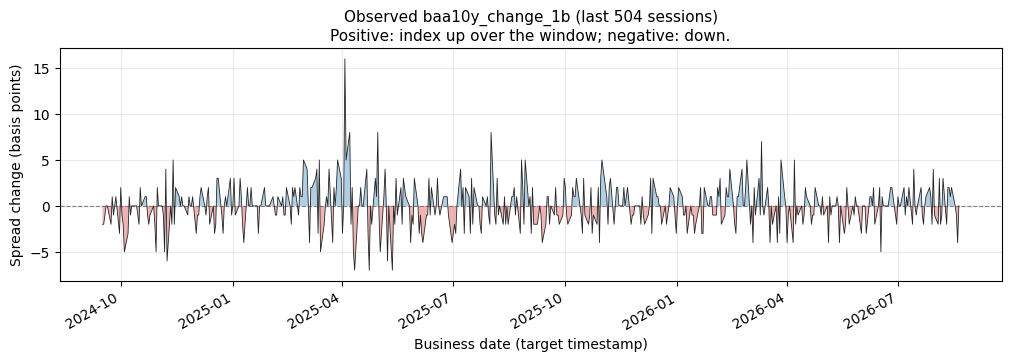

In [7]:
fig, _ = plot_baa10y_spread_change_recent(svc, n_trading_days=504) # Approximately two years
plt.show()

In [8]:
fig = plotly_baa10y_spread_change_recent(svc, n_trading_days=504) # Approximately two years
fig

---
## 4. Predictors — configured in code

This is where you choose the roster. Each predictor implements the same
`Predictor` API against the loaded spec; the conventional methods come straight
from `aieng.forecasting.methods`, and the LLM-Process variants come from the
BAA10Y recipe in `predictors/`. The covariate variants read the registered
`COVARIATES` panel; the target-only variants pass `covariate_series_ids=None`.

| Group | Predictor | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | `DartsExponentialSmoothingPredictor` (ETS), `DartsKalmanForecasterPredictor` | — |
| ML regression | `DartsLinearRegressionPredictor`, `DartsLightGBMPredictor` | target-only **and** + panel |
| LLM-Process | `build_sp500_llmp_sampled_trajectory` | target-only **and** + panel (post-cutoff only) |

`AutoARIMA` is left commented (accurate but slow); add it back for a classical
sweep. The `LLMP (target)` vs `LLMP + cov` pair is the centerpiece — its CRPS gap
answers whether an LLM can use the same exogenous panel the ML methods do.

In [6]:
# Shared hyperparameters for the Darts regression models.
LAGS = 5  # autoregressive lags (and past-covariate lags) for the regression models
NUM_SAMPLES = 100  # empirical-quantile sample count for the probabilistic Darts models
LGBM_KWARGS = {"num_threads": 1, "n_jobs": 1, "verbosity": -1}

# ── Naive floor + classical (univariate) ──────────────────────────────────────
naive = LastValuePredictor()
ets = DartsExponentialSmoothingPredictor(num_samples=NUM_SAMPLES)
kalman = DartsKalmanForecasterPredictor(num_samples=NUM_SAMPLES)
autoarima = DartsAutoARIMAPredictor(num_samples=NUM_SAMPLES)  # accurate but the slowest classical method

# ── ML regression — target-only vs the covariate panel ────────────────────────
linreg = DartsLinearRegressionPredictor(lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES)
linreg_cov = DartsLinearRegressionPredictor(
    lags=LAGS, lags_past_covariates=LAGS, covariate_series_ids=COVARIATES, num_samples=NUM_SAMPLES
)
lightgbm = DartsLightGBMPredictor(
    lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES, lgbm_kwargs=LGBM_KWARGS
)
lightgbm_cov = DartsLightGBMPredictor(
    lags=LAGS,
    lags_past_covariates=LAGS,
    covariate_series_ids=COVARIATES,
    num_samples=NUM_SAMPLES,
    lgbm_kwargs=LGBM_KWARGS,
)

all_predictors = [naive, ets, kalman, autoarima, linreg, linreg_cov, lightgbm, lightgbm_cov]

# Which covariate panel each predictor consumes — drives the leaderboard's
# covariate columns. Predictors absent from this map are treated as target-only.
PREDICTOR_COVARIATES = {
    linreg_cov.predictor_id: COVARIATES,
    lightgbm_cov.predictor_id: COVARIATES,
}
# Short labels for the leaderboard "model" column and the CRPS charts.
PREDICTOR_LABELS = {
    naive.predictor_id: "Naive",
    ets.predictor_id: "ETS",
    kalman.predictor_id: "Kalman",
    autoarima.predictor_id: "AutoARIMA",
    linreg.predictor_id: "LinReg",
    linreg_cov.predictor_id: "LinReg + cov",
    lightgbm.predictor_id: "LightGBM",
    lightgbm_cov.predictor_id: "LightGBM + cov",
}

# ── LLM-Process (sampled trajectories) — target-only vs with-covariates ────────
# Gated on POST_CUTOFF: the 2020 stress window is pre-cutoff and leaked for LLMs,
# so we keep the LLMP rows out of that comparison entirely. The recipe (prompt
# framing, defaults) lives in predictors/llmp_sampled_trajectory.py; tune it
# there, or override model= / n_samples= / history_window= per call here.
if POST_CUTOFF:
    llmp = build_baa10y_llmp_sampled_trajectory(n_samples=8, history_window=48)
    llmp_cov = build_baa10y_llmp_sampled_trajectory(n_samples=8, history_window=48, covariate_series_ids=COVARIATES)
    all_predictors += [llmp, llmp_cov]
    PREDICTOR_COVARIATES[llmp_cov.predictor_id] = COVARIATES
    PREDICTOR_LABELS[llmp.predictor_id] = "LLMP (target)"
    PREDICTOR_LABELS[llmp_cov.predictor_id] = "LLMP + cov"

print(f"{len(all_predictors)} predictors configured (LLMP {'on' if POST_CUTOFF else 'off'}):")
for p in all_predictors:
    print(f"  {p.predictor_id}")

10 predictors configured (LLMP on):
  last_value_naive
  darts_ets
  darts_kalman
  darts_autoarima
  darts_linreg
  darts_linreg_cov
  darts_lightgbm
  darts_lightgbm_cov
  llmp_sampled_trajectories_baa10y_v1_target_h48_n8[gemini-3.1-flash-lite-preview]
  llmp_sampled_trajectories_baa10y_v1_cov_h48_n8[gemini-3.1-flash-lite-preview]


In [7]:
# ── LightGBM: vanilla vs. per-quantile-tuned — one switch for both ─────────────
#
# LIGHTGBM_MODE controls which LightGBM row(s) land in `all_predictors`:
#   "vanilla"  only the original lightgbm/lightgbm_cov from the cell above —
#              no tuning run, fastest, unchanged pre-tuning behavior.
#   "tuned"    only the per-quantile-tuned pair — replaces the vanilla rows.
#   "both"     vanilla AND tuned side by side (default) — easiest for a direct
#              CRPS comparison in the Section 5 leaderboard.
LIGHTGBM_MODE = "both"  # "vanilla" | "tuned" | "both"
from aieng.forecasting.methods.numerical import ParamRange, tune_lightgbm_configs

# TUNING_TASK_ID picks which of backtest_spec's 3 tasks the tuner optimizes
# against. The winning config is then used to build ONE lightgbm_tuned /
# lightgbm_cov_tuned pair that gets applied to ALL 3 horizon tasks below (the
# notebook runs one predictor instance across the whole MultiTargetBacktestSpec
# — see docs/lightgbm-quantile-tuning-guide.md for why this is a one-shared-
# search tradeoff, not per-horizon tuning).
#   "baa10y_change_1b"   next-session change
#   "baa10y_change_5b"   forward 1-week change    (default — a horizon midpoint)
#   "baa10y_change_21b"  forward 1-month change   — switch to this string to
#                         tune for the longer-horizon task instead.
TUNING_TASK_ID = "baa10y_change_5b"

# LGBM_TUNING_MODE controls whether the Optuna search below starts over,
# reuses a prior session's result with zero new trials, or resumes a prior
# session up to n_trials total (see docs/lightgbm-quantile-tuning-guide.md
# §7). Ignored when LIGHTGBM_MODE == "vanilla" (no tuning runs at all).
#   "scratch"  always re-run the full search from nothing — use this the
#              first time, or whenever param_ranges/lags/covariates change
#              (mixing those changes into a reused/resumed study is unsafe —
#              see §7's caveat).
#   "reuse"    load the last saved config, run zero new trials — fastest,
#              raises if no saved study exists yet for TUNING_TASK_ID.
#   "resume"   load the last saved config and run only enough additional
#              trials to reach n_trials total — cheaper than "scratch" once
#              a study already exists, without freezing the search early.
LGBM_TUNING_MODE = "resume"  # "scratch" | "reuse" | "resume"

# LGBM_TUNING_DB is the SQLite file the Optuna study is saved to/loaded from
# across notebook sessions. Lives under this implementation's own data/ dir,
# already gitignored via the repo's `implementations/**/data/` rule — same
# convention as PREDICTIONS_DIR above, no new .gitignore entries needed.
LGBM_TUNING_DB = ROOT / "data" / "lgbm_tuning" / "optuna_studies.db"

if LIGHTGBM_MODE not in {"vanilla", "tuned", "both"}:
    raise ValueError(f"Unknown LIGHTGBM_MODE: {LIGHTGBM_MODE!r}")
if LGBM_TUNING_MODE not in {"scratch", "reuse", "resume"}:
    raise ValueError(f"Unknown LGBM_TUNING_MODE: {LGBM_TUNING_MODE!r}")

if LIGHTGBM_MODE != "vanilla":
    from datetime import datetime

    from aieng.forecasting.methods.numerical import tune_lightgbm_configs

    tuning_task = next(t for t in backtest_spec.tasks if t.task_id == TUNING_TASK_ID)

    # Narrower than the library default — n_estimators/num_leaves capped lower to
    # avoid sampling the large-tree x 55-feature corner that cost ~2.5 hours/trial
    # on the covariate variant. Halves both the base range AND the slope range for
    # each, since slope alone can still push tail-quantile values back up near the
    # original ceiling otherwise.
    CHEAPER_PARAM_RANGES = {
        "num_leaves": ParamRange(8, 64, -32, 32),         # was (8, 128, -64, 64) in the library default
        "max_depth": ParamRange(3, 12, -6, 6),             # unchanged
        "min_data_in_leaf": ParamRange(5, 100, -50, 50),   # unchanged
        "lambda_l1": ParamRange(0.0, 5.0, -2.0, 2.0),      # unchanged
        "lambda_l2": ParamRange(0.0, 5.0, -2.0, 2.0),      # unchanged
        "learning_rate": ParamRange(0.01, 0.3, -0.1, 0.1, log=True),  # unchanged
        "n_estimators": ParamRange(50, 250, -100, 100),    # was (50, 500, -200, 200) — this is the biggest cost lever
    }

    tuned = tune_lightgbm_configs(
        task=tuning_task,
        data_service=svc,
        #validation_end=datetime(2020, 1, 31),  # strictly before stress_2020's first origin
        validation_end=datetime(2024, 12, 20),  # strictly before stress_2020's first origin. Changed so that
        cutoff=datetime(2025, 1, 6),  # = backtest_spec.start; enforces no-leakage (raises if violated)
        # COVARIATES already reflects whatever is registered in `svc` — e.g. once
        # a regime-change indicator (the planned RAG-derived signal) is added to
        # DEFAULT_COVARIATE_SERIES_IDS in data.py, following the same optional-
        # covariate pattern HYOAS_OPTIONAL_COVARIATE_SERIES_IDS already uses in
        # Section 8, it flows through here automatically — nothing in this cell
        # needs to change. If that new series is CATEGORICAL rather than
        # continuous, encode it numerically first (e.g. ordinal or one-hot) —
        # Darts past covariates are numeric-only, same requirement as any other
        # covariate in this notebook.
        covariate_series_ids=COVARIATES,
        lags=LAGS,
        param_ranges=CHEAPER_PARAM_RANGES,   # <-- add this line to the existing call
        base_lgbm_kwargs=LGBM_KWARGS,  # already pins num_threads=1 — no oversubscription with n_jobs below
        #validation_window=60,  # trailing business days of already-known outcomes
        validation_window=120,  # trailing business days of already-known outcomes
        warmup=250,  # mirrors the spec's own warmup convention
        n_trials=27,  # start modest — see docs/lightgbm-quantile-tuning-guide.md §6 before scaling up
        n_jobs=4,  # Optuna trial-level parallelism — this machine's 4 physical cores, minus 1 free
        storage_path=LGBM_TUNING_DB,  # save/resume across sessions — see §7
        mode=LGBM_TUNING_MODE,
    )
    print(f"[{TUNING_TASK_ID}] univariate validation CRPS: {tuned['univariate'].best_score:.4f}")
    print(f"[{TUNING_TASK_ID}] covariate  validation CRPS: {tuned['covariate'].best_score:.4f}")
    print(
        f"[{TUNING_TASK_ID}] mode={LGBM_TUNING_MODE!r}, total trials so far: "
        f"univariate={tuned['univariate'].n_trials}, covariate={tuned['covariate'].n_trials}"
    )

    lightgbm_tuned = DartsLightGBMPredictor(
        lags=LAGS,
        covariate_series_ids=None,
        num_samples=NUM_SAMPLES,
        lgbm_kwargs=LGBM_KWARGS,
        per_quantile_kwargs=tuned["univariate"].per_quantile_kwargs,
    )
    lightgbm_cov_tuned = DartsLightGBMPredictor(
        lags=LAGS,
        lags_past_covariates=LAGS,
        covariate_series_ids=COVARIATES,
        num_samples=NUM_SAMPLES,
        lgbm_kwargs=LGBM_KWARGS,
        per_quantile_kwargs=tuned["covariate"].per_quantile_kwargs,
    )
    PREDICTOR_COVARIATES[lightgbm_cov_tuned.predictor_id] = COVARIATES
    PREDICTOR_LABELS[lightgbm_tuned.predictor_id] = "LightGBM (tuned)"
    PREDICTOR_LABELS[lightgbm_cov_tuned.predictor_id] = "LightGBM + cov (tuned)"

    if LIGHTGBM_MODE == "tuned":
        # Drop the vanilla rows so the leaderboard shows tuned-only.
        all_predictors = [p for p in all_predictors if p not in (lightgbm, lightgbm_cov)]
    all_predictors += [lightgbm_tuned, lightgbm_cov_tuned]

print(f"LIGHTGBM_MODE={LIGHTGBM_MODE!r} — {len(all_predictors)} predictors configured:")
for p in all_predictors:
    print(f"  {p.predictor_id}")

[I 2026-08-31 13:55:50,885] Using an existing study with name 'baa10y_change_5b_univariate' instead of creating a new one.
[I 2026-08-31 13:55:51,025] Using an existing study with name 'baa10y_change_5b_covariate' instead of creating a new one.


[baa10y_change_5b] univariate validation CRPS: 2.9537
[baa10y_change_5b] covariate  validation CRPS: 2.9319
[baa10y_change_5b] mode='resume', total trials so far: univariate=27, covariate=27
LIGHTGBM_MODE='both' — 12 predictors configured:
  last_value_naive
  darts_ets
  darts_kalman
  darts_autoarima
  darts_linreg
  darts_linreg_cov
  darts_lightgbm
  darts_lightgbm_cov
  llmp_sampled_trajectories_baa10y_v1_target_h48_n8[gemini-3.1-flash-lite-preview]
  llmp_sampled_trajectories_baa10y_v1_cov_h48_n8[gemini-3.1-flash-lite-preview]
  darts_lightgbm_tuned
  darts_lightgbm_cov_tuned


---
## 5. 2025 backtest — the comparison (post-cutoff)

`cached_multi_backtest` runs each predictor across the three single-horizon tasks
and writes every `BacktestResult` to `data/predictions/<spec_id>/` — so a re-run
is free from cache (pass `force_refresh=True` to recompute). The loop prints each
task's mean CRPS as it lands.

In [8]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:18s}  mean CRPS = {result.mean_score:.5f}  ({len(result.predictions)} preds)")

RESULTS_DF = build_leaderboard(
    results_by_predictor,
    svc,
    covariates_by_predictor=PREDICTOR_COVARIATES,
    labels_by_predictor=PREDICTOR_LABELS,
)

Running last_value_naive ...
  baa10y_change_1b    mean CRPS = 2.50980  (51 preds)
  baa10y_change_5b    mean CRPS = 6.80392  (51 preds)
  baa10y_change_21b   mean CRPS = 10.07843  (51 preds)
Running darts_ets ...
  baa10y_change_1b    mean CRPS = 1.31614  (51 preds)
  baa10y_change_5b    mean CRPS = 5.19350  (51 preds)
  baa10y_change_21b   mean CRPS = 8.52345  (51 preds)
Running darts_kalman ...
  baa10y_change_1b    mean CRPS = 1.30176  (51 preds)
  baa10y_change_5b    mean CRPS = 3.85555  (51 preds)
  baa10y_change_21b   mean CRPS = 6.48147  (51 preds)
Running darts_autoarima ...
  baa10y_change_1b    mean CRPS = 1.31231  (51 preds)
  baa10y_change_5b    mean CRPS = 3.95273  (51 preds)
  baa10y_change_21b   mean CRPS = 7.71943  (51 preds)
Running darts_linreg ...
  baa10y_change_1b    mean CRPS = 1.14682  (51 preds)
  baa10y_change_5b    mean CRPS = 3.46438  (51 preds)
  baa10y_change_21b   mean CRPS = 6.90643  (51 preds)
Running darts_linreg_cov ...
  baa10y_change_1b    mean CRPS

ValueError: The `past_covariates` are not long enough. Given horizon `n=21`, `min(lags_past_covariates)=-5`, `max(lags_past_covariates)=-1` and `output_chunk_length=21`, the `past_covariates` have to range from 2025-01-14 00:00:00 until 2025-01-20 00:00:00 (inclusive), but they only range from 2016-01-15 00:00:00 until 2025-01-17 00:00:00.
predict() failed at origin 2025-01-20 (attempt 1/3): The `past_covariates` are not long enough. Given horizon `n=21`, `min(lags_past_covariates)=-5`, `max(lags_past_covariates)=-1` and `output_chunk_length=21`, the `past_covariates` have to range from 2025-01-14 00:00:00 until 2025-01-20 00:00:00 (inclusive), but they only range from 2016-01-15 00:00:00 until 2025-01-17 00:00:00. — retrying in 2s
ValueError: The `past_covariates` are not long enough. Given horizon `n=21`, `min(lags_past_covariates)=-5`, `max(lags_past_covariates)=-1` and `output_chunk_length=21`, the `past_covariates` have to range from 2025-01-14 00:00:00 until 2025-01-20 00:00:00 (

  baa10y_change_1b    mean CRPS = 1.25773  (47 preds)
  baa10y_change_5b    mean CRPS = 3.69385  (47 preds)
  baa10y_change_21b   mean CRPS = 6.65044  (47 preds)
Running llmp_sampled_trajectories_baa10y_v1_target_h48_n8[gemini-3.1-flash-lite-preview] ...
  baa10y_change_1b    mean CRPS = 1.49224  (51 preds)
  baa10y_change_5b    mean CRPS = 3.97641  (51 preds)
  baa10y_change_21b   mean CRPS = 8.25078  (51 preds)
Running llmp_sampled_trajectories_baa10y_v1_cov_h48_n8[gemini-3.1-flash-lite-preview] ...


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x782368349eb0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x78236833f850>, 7214.37736114), (<aiohttp.client_proto.ResponseHandler object at 0x78236833f3f0>, 7214.403546532), (<aiohttp.client_proto.ResponseHandler object at 0x78236833f770>, 7214.40677816), (<aiohttp.client_proto.ResponseHandler object at 0x78236833f930>, 7214.467489661), (<aiohttp.client_proto.ResponseHandler object at 0x78236833f540>, 7214.46921484), (<aiohttp.client_proto.ResponseHandler object at 0x78236833f690>, 7214.480469071), (<aiohttp.client_proto.ResponseHandler object at 0x78236833f460>, 7214.48273506), (<aiohttp.client_proto.ResponseHandler object at 0x78236833f2a0>, 7214.585207369)])']
connector: <aiohttp.connector.TCPConnector object at 0x7823683778f0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7823683afe90>
Unclosed connector
connections: ['d

  baa10y_change_1b    mean CRPS = 1.55230  (51 preds)
  baa10y_change_5b    mean CRPS = 4.22834  (51 preds)
  baa10y_change_21b   mean CRPS = 8.31677  (51 preds)
Running darts_lightgbm_tuned ...


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x78236a5539e0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x78236a5dfaf0>, 7310.046796848), (<aiohttp.client_proto.ResponseHandler object at 0x78236a5dfd20>, 7310.048614037), (<aiohttp.client_proto.ResponseHandler object at 0x78236a5dfcb0>, 7310.070151392), (<aiohttp.client_proto.ResponseHandler object at 0x78236a5dfa10>, 7310.081984935), (<aiohttp.client_proto.ResponseHandler object at 0x78236a5def90>, 7310.15936673), (<aiohttp.client_proto.ResponseHandler object at 0x78236a5df770>, 7310.184689565), (<aiohttp.client_proto.ResponseHandler object at 0x78236a5df700>, 7310.221340559), (<aiohttp.client_proto.ResponseHandler object at 0x78236a5dfbd0>, 7310.244299495)])']
connector: <aiohttp.connector.TCPConnector object at 0x78236a47e630>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x78236a5f32f0>
Unclosed connector
connections: 

  baa10y_change_1b    mean CRPS = 1.18561  (51 preds)
  baa10y_change_5b    mean CRPS = 3.47280  (51 preds)
  baa10y_change_21b   mean CRPS = 6.78603  (51 preds)
Running darts_lightgbm_cov_tuned ...


ValueError: The `past_covariates` are not long enough. Given horizon `n=1`, `min(lags_past_covariates)=-5`, `max(lags_past_covariates)=-1` and `output_chunk_length=1`, the `past_covariates` have to range from 2025-01-14 00:00:00 until 2025-01-20 00:00:00 (inclusive), but they only range from 2016-01-15 00:00:00 until 2025-01-17 00:00:00.
predict() failed at origin 2025-01-20 (attempt 1/3): The `past_covariates` are not long enough. Given horizon `n=1`, `min(lags_past_covariates)=-5`, `max(lags_past_covariates)=-1` and `output_chunk_length=1`, the `past_covariates` have to range from 2025-01-14 00:00:00 until 2025-01-20 00:00:00 (inclusive), but they only range from 2016-01-15 00:00:00 until 2025-01-17 00:00:00. — retrying in 2s
ValueError: The `past_covariates` are not long enough. Given horizon `n=1`, `min(lags_past_covariates)=-5`, `max(lags_past_covariates)=-1` and `output_chunk_length=1`, the `past_covariates` have to range from 2025-01-14 00:00:00 until 2025-01-20 00:00:00 (inclus

  baa10y_change_1b    mean CRPS = 1.13957  (47 preds)
  baa10y_change_5b    mean CRPS = 3.41104  (47 preds)
  baa10y_change_21b   mean CRPS = 6.80113  (47 preds)


### Leaderboard — mean CRPS by method and horizon

Read it as a story: the spread between methods (and the naive floor's
disadvantage) is widest at `h=1` and compresses by `h=21`. The `dir_*` columns
report next-direction skill (most meaningful at `h=1`).

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval
0,1,baa10y_change_1b,LightGBM + cov (tuned),True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov_tuned,1.13957,47,47,4,0.529,0.450,0.486,0.596,0.583,47
1,1,baa10y_change_1b,LinReg,False,0,—,darts_linreg,1.14682,51,51,0,0.000,0.000,0.000,0.569,0.584,51
2,1,baa10y_change_1b,LinReg + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_linreg_cov,1.16398,47,47,4,1.000,0.050,0.095,0.596,0.493,47
3,1,baa10y_change_1b,LightGBM (tuned),False,0,—,darts_lightgbm_tuned,1.18561,51,51,0,0.385,0.238,0.294,0.529,0.445,51
4,1,baa10y_change_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,1.25773,47,47,4,0.318,0.350,0.333,0.404,0.324,47
5,1,baa10y_change_1b,LightGBM,False,0,—,darts_lightgbm,1.28979,51,51,0,0.357,0.238,0.286,0.510,0.392,51
6,1,baa10y_change_1b,Kalman,False,0,—,darts_kalman,1.30176,51,51,0,0.455,0.714,0.556,0.529,0.514,51
7,1,baa10y_change_1b,AutoARIMA,False,0,—,darts_autoarima,1.31231,51,51,0,0.357,0.476,0.408,0.431,0.419,51
8,1,baa10y_change_1b,ETS,False,0,—,darts_ets,1.31614,51,51,0,0.375,0.429,0.400,0.471,0.462,51
9,1,baa10y_change_1b,LLMP (target),False,0,—,llmp_sampled_trajectories_baa10y_v1_target_h48_n8[gemini-3.1-flash-lite-preview],1.49224,51,51,0,0.444,0.190,0.267,0.569,0.401,51


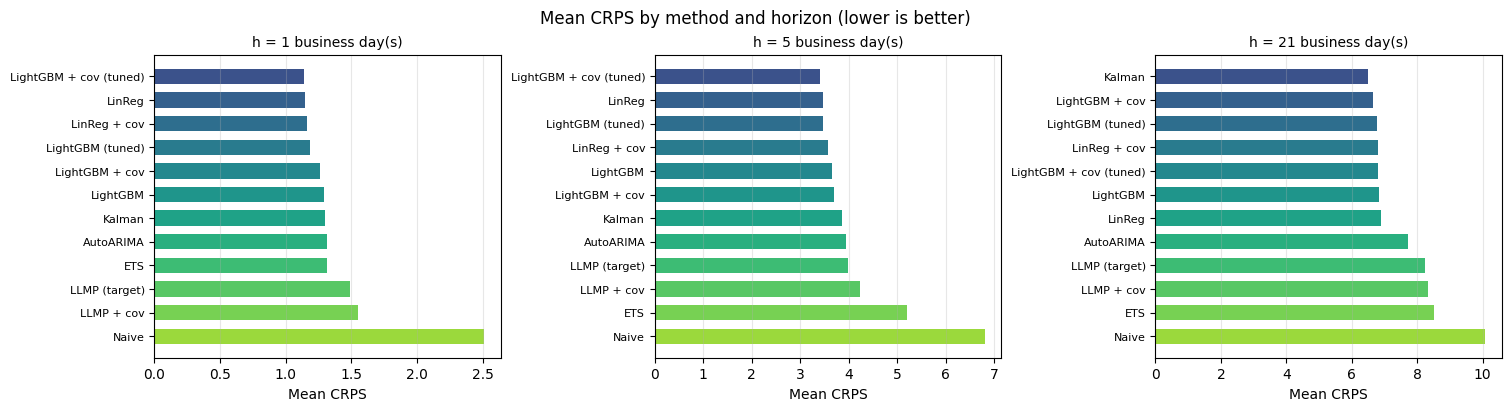

In [9]:
display_multivariate_backtest_leaderboard(RESULTS_DF)

In [11]:
plotly_display_multivariate_backtest_leaderboard(RESULTS_DF)

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval
0,1,baa10y_change_1b,LightGBM,False,0,—,darts_lightgbm,0.80168,6,6,0,0.500,0.667,0.571,0.500,0.444,6
1,1,baa10y_change_1b,LinReg,False,0,—,darts_linreg,0.83446,6,6,0,0.000,0.000,0.000,0.500,0.833,6
2,1,baa10y_change_1b,LinReg + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_linreg_cov,0.89244,6,6,0,0.000,0.000,0.000,0.500,0.333,6
3,1,baa10y_change_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.92892,6,6,0,0.333,0.333,0.333,0.333,0.333,6
4,1,baa10y_change_1b,Kalman,False,0,—,darts_kalman,1.05719,6,6,0,0.333,0.333,0.333,0.333,0.333,6
5,1,baa10y_change_1b,ETS,False,0,—,darts_ets,1.08501,6,6,0,0.500,0.333,0.400,0.500,0.556,6
6,1,baa10y_change_1b,AutoARIMA,False,0,—,darts_autoarima,1.14330,6,6,0,0.333,0.333,0.333,0.333,0.222,6
7,1,baa10y_change_1b,LLMP (target),False,0,—,llmp_sampled_trajectories_baa10y_v1_target_h48_n8[gemini-3.1-flash-lite-preview],1.14966,6,6,0,0.000,0.000,0.000,0.500,0.667,6
8,1,baa10y_change_1b,LLMP + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",llmp_sampled_trajectories_baa10y_v1_cov_h48_n8[gemini-3.1-flash-lite-preview],1.33548,6,6,0,0.000,0.000,0.000,0.167,0.222,6
9,1,baa10y_change_1b,Naive,False,0,—,last_value_naive,2.00000,6,6,0,1.000,0.333,0.500,0.667,0.556,6


### Reading the LLMP ± covariates rows

When the LLM-Process rows are present (post-cutoff windows), compare them directly:
- **LLMP (target)** — the LLM sees **only** the return history.
- **LLMP + cov** — it additionally sees **labeled covariate-history blocks**
  (VIX, yields, …) in its prompt.

Their CRPS gap answers the headline question: does the same exogenous panel the
ML methods use help an LLM — and does either LLMP variant reach the
gradient-boosting rows? Because these windows are **post-cutoff**, the LLM can't
be reciting memorised outcomes.

---
## 6. Forecast vs realised (next session, h=1)

A few models' median next-session forecast against the realised return (percent)
— the near-zero, low-amplitude forecasts vs the noisy realised series are the
daily-efficiency story made visual. These reuse the cached `h=1` predictions from
Section 5 (no re-running).

In [2]:
# A few representative models, pulled straight from the cached backtest results.
H1_TASK = "baa10y_change_1b"
demo_ids = [naive.predictor_id, ets.predictor_id, lightgbm_cov.predictor_id]

compare_by_run: dict[str, pd.DataFrame] = {}
for pid in demo_ids:
    result = results_by_predictor.get(pid, {}).get(H1_TASK)
    if result is None:
        continue
    label = PREDICTOR_LABELS.get(pid, pid)
    compare_by_run[label] = build_spread_change_compare_frame(result.predictions, svc, H1_TASK)

fig, _ = plot_spread_change_forecast_vs_actual_multi(compare_by_run, title="Next-session change: forecast vs realised (h=1)")
plt.show()

NameError: name 'naive' is not defined

In [13]:
plotly_spread_change_forecast_vs_actual_multi(compare_by_run, title="Next-session change: forecast vs realised (h=1)")


---
## 7. Protected 2026 eval — the honest scoreboard

`multi_evaluate()` against the held-out 2026 window. This is **scarce**:
`baa10y_eval_2026.yaml` carries `max_runs`, and one `multi_evaluate` call across
all three horizons counts as **one** run. Pass an `EvalTracker` to enforce that
budget across sessions (commented below — it would block re-runs once exhausted,
so we leave it off here and just show `run_number`).

Spend it on the models you committed to from the 2025 backtest — pick a small
**finalists** list in the cell below, not the whole roster. Unlike Section 5,
`multi_evaluate()` itself never auto-caches — but the cell below has a
`SAVE_EVAL_RESULTS` toggle (default on) that explicitly persists each run via
`save_multi_eval_results` to `data/predictions/baa10y_eval_2026/`, since a run
here permanently spends part of the budget and is otherwise easy to lose once
the kernel closes.

> **Runtime:** the finalists default to the cutoff-safe baselines plus
> `LightGBM + cov`. Add the LLMP variants when you're ready to spend the proxy
> tokens on the protected scoreboard (each LLMP eval is ~8 origins × 3 horizons ×
> `n_samples` calls).

In [ ]:
# from aieng.forecasting.evaluation import EvalTracker
# tracker = EvalTracker(ROOT / "data" / "baa10y_eval_runs.yaml")  # enforces max_runs across sessions

# SAVE_EVAL_RESULTS controls whether each multi_evaluate() call below also gets
# persisted to disk via save_multi_eval_results, as
#   data/predictions/baa10y_eval_2026/<predictor_id>__<task_id>__eval_run<N>.yaml
# Unlike Section 5 (auto-cached by cached_multi_backtest), eval runs are NOT
# persisted automatically — by default they only live in this kernel's
# eval_results/EVAL_DF variables, which is easy to lose given a run here also
# permanently consumes part of the scarce max_runs budget above (5 runs total,
# shared across every predictor, forever — see the max_runs discussion). The
# filename bakes in run_number, so turning this on never overwrites a prior
# run's file. Default True: losing a run you can't repeat is worse than a
# small extra YAML file. Set False if you want to keep a pass purely
# exploratory and not write anything to disk yet.
SAVE_EVAL_RESULTS = True

with (SPECS_DIR / _EVAL_SPEC_FILE).open() as f:
    eval_spec = MultiTargetEvalSpec.model_validate(yaml.safe_load(f))

# Finalists only — the held-out window is scarce. Pick the handful you committed
# to from the 2025 backtest (e.g. add `llmp`, `llmp_cov` here when ready to spend
# the proxy tokens — they exist only when POST_CUTOFF).
eval_finalists = [naive, lightgbm_cov]

eval_results: dict[str, dict[str, object]] = {}
for predictor in eval_finalists:
    print(f"Evaluating {predictor.predictor_id} ...", flush=True)
    eval_results[predictor.predictor_id] = multi_evaluate(
        predictor=predictor,
        spec=eval_spec,
        data_service=svc,
        tracker=None,  # set to `tracker` above to enforce the max_runs budget
    )
    if SAVE_EVAL_RESULTS:
        saved_paths = save_multi_eval_results(eval_results[predictor.predictor_id], eval_spec)
        print(f"  saved {len(saved_paths)} file(s) under data/predictions/{eval_spec.spec_id}/")
    for task_id, result in eval_results[predictor.predictor_id].items():
        print(f"  {task_id:18s}  mean CRPS = {result.mean_score:.5f}  (run #{result.run_number})")

EVAL_DF = build_leaderboard(
    eval_results,
    svc,
    covariates_by_predictor=PREDICTOR_COVARIATES,
    labels_by_predictor=PREDICTOR_LABELS,
)

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,run_number
0,1,baa10y_change_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,1.90028,8,8,0,0.500,0.500,0.500,0.500,0.688,8,1
1,1,baa10y_change_1b,Naive,False,0,—,last_value_naive,3.00000,8,8,0,1.000,0.500,0.667,0.750,0.562,8,1
2,5,baa10y_change_5b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,3.40485,8,8,0,0.750,0.500,0.600,0.500,0.417,8,1
3,5,baa10y_change_5b,Naive,False,0,—,last_value_naive,6.50000,8,8,0,0.667,0.667,0.667,0.500,0.333,8,1
4,21,baa10y_change_21b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,8.19381,8,8,0,0.000,0.000,0.000,0.500,0.625,8,1
5,21,baa10y_change_21b,Naive,False,0,—,last_value_naive,16.50000,8,8,0,0.333,0.500,0.400,0.250,0.250,8,1


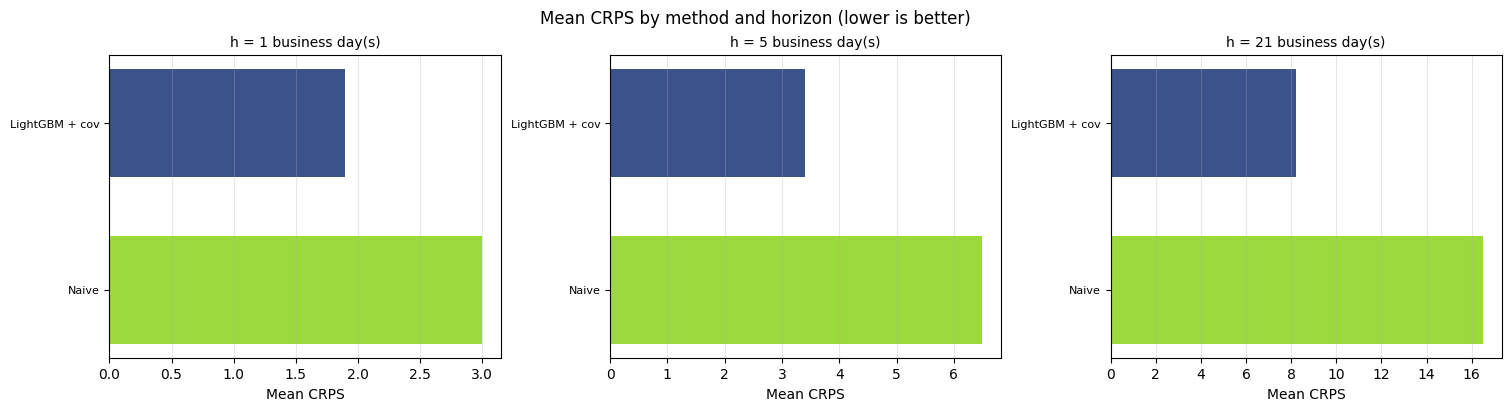

In [15]:
display_multivariate_backtest_leaderboard(EVAL_DF)

In [16]:
plotly_display_multivariate_backtest_leaderboard(EVAL_DF)

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,run_number
0,1,baa10y_change_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,1.90028,8,8,0,0.500,0.500,0.500,0.500,0.688,8,1
1,1,baa10y_change_1b,Naive,False,0,—,last_value_naive,3.00000,8,8,0,1.000,0.500,0.667,0.750,0.562,8,1
2,5,baa10y_change_5b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,3.40485,8,8,0,0.750,0.500,0.600,0.500,0.417,8,1
3,5,baa10y_change_5b,Naive,False,0,—,last_value_naive,6.50000,8,8,0,0.667,0.667,0.667,0.500,0.333,8,1
4,21,baa10y_change_21b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,8.19381,8,8,0,0.000,0.000,0.000,0.500,0.625,8,1
5,21,baa10y_change_21b,Naive,False,0,—,last_value_naive,16.50000,8,8,0,0.333,0.500,0.400,0.250,0.250,8,1


## 8. Comparison between with HYOAS and without generated by ChatGTP 5.6


In [2]:

BASELINE_PREDICTOR_ID = lightgbm_cov.predictor_id
# Expected: "darts_lightgbm_cov"

if BASELINE_PREDICTOR_ID not in results_by_predictor:
    raise RuntimeError(
        "The existing LightGBM + covariates result is unavailable. "
        "Run the main backtest section above first."
    )

without_hyoas_results = results_by_predictor[BASELINE_PREDICTOR_ID]
for task_id, result in without_hyoas_results.items():
    print(
        f"  {task_id:20s} "
        f"mean CRPS = {result.mean_score:.5f} "
        f"({len(result.predictions)} predictions)"
    )


NameError: name 'lightgbm_cov' is not defined

In [27]:
# ---------------------------------------------------------------------------
# Build a service containing baseline covariates plus HYOAS
# ---------------------------------------------------------------------------

HYOAS_COVARIATES = list(
    dict.fromkeys([
        *DEFAULT_COVARIATE_SERIES_IDS,
        *HYOAS_OPTIONAL_COVARIATE_SERIES_IDS,
    ])
)

svc_hyoas = build_baa10y_multivariate_service(
    windows=(1, 5, 21),
    include_covariates=True,
    covariate_series_ids=HYOAS_COVARIATES,
    start=DATA_HISTORY_START,
    refresh=REFRESH_CACHE,
)

registered_series = set(svc_hyoas.series_ids)

missing_hyoas = [
    series_id
    for series_id in HYOAS_OPTIONAL_COVARIATE_SERIES_IDS
    if series_id not in registered_series
]

if missing_hyoas:
    raise RuntimeError(
        f"Missing HYOAS covariates: {missing_hyoas}"
    )

HYOAS_COVARIATES = [
    series_id
    for series_id in HYOAS_COVARIATES
    if series_id in registered_series
]

print(f"\nHYOAS model covariates: {len(HYOAS_COVARIATES)}")
print(
    "Added HYOAS covariates:",
    list(HYOAS_OPTIONAL_COVARIATE_SERIES_IDS),
)
ab_hyoas_predictor = DartsLightGBMPredictor(
    lags=LAGS,
    lags_past_covariates=LAGS,
    covariate_series_ids=HYOAS_COVARIATES,
    num_samples=NUM_SAMPLES,
    lgbm_kwargs=LGBM_KWARGS,
)

with_hyoas_results = cached_multi_backtest(
    predictor=ab_hyoas_predictor,
    spec=backtest_spec,
    data_service=svc_hyoas,
    store_dir=PREDICTIONS_DIR / "hyoas_ab" / "with_hyoas",
)


# Combine the existing baseline and new HYOAS results
hyoas_comparison_results = {
    "LightGBM without HYOAS": without_hyoas_results,
    "LightGBM with HYOAS": with_hyoas_results,
}


# Display CRPS
summary_rows = []

for experiment, task_results in hyoas_comparison_results.items():
    for task_id, result in task_results.items():
        summary_rows.append({
            "experiment": experiment,
            "task": task_id,
            "mean_crps": result.mean_score,
            "predictions": len(result.predictions),
        })

HYOAS_AB_SUMMARY = pd.DataFrame(summary_rows)
display(HYOAS_AB_SUMMARY)



HYOAS model covariates: 12
Added HYOAS covariates: ['hyoas_observed_change_1b_bps_l1b', 'hyoas_hyg_dgs3_proxy_change_1b_bps_l1b']


,experiment,task,mean_crps,predictions
0,LightGBM without HYOAS,baa10y_change_1b,0.928924,6
1,LightGBM without HYOAS,baa10y_change_5b,4.312066,6
2,LightGBM without HYOAS,baa10y_change_21b,7.137142,6
3,LightGBM with HYOAS,baa10y_change_1b,0.972399,6
4,LightGBM with HYOAS,baa10y_change_5b,4.254950,6
5,LightGBM with HYOAS,baa10y_change_21b,8.034777,6


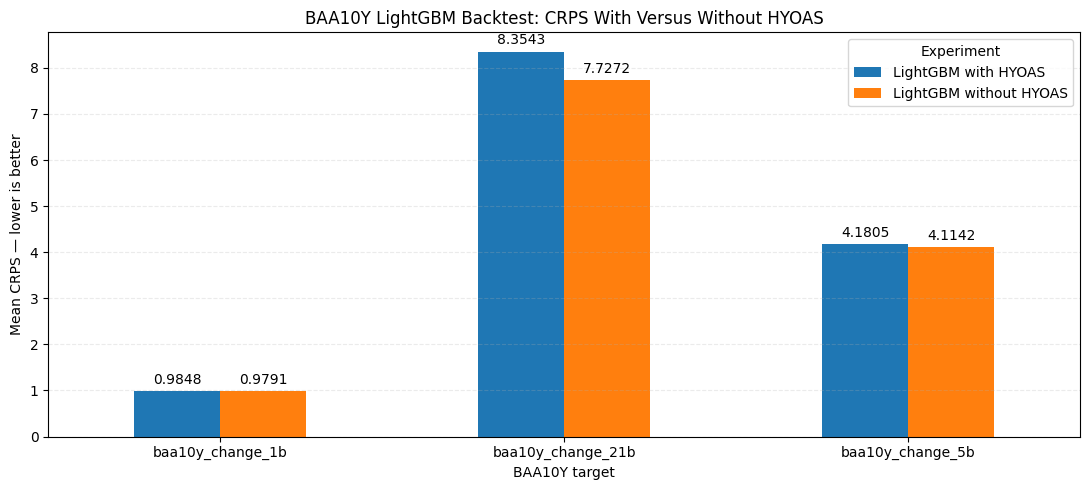

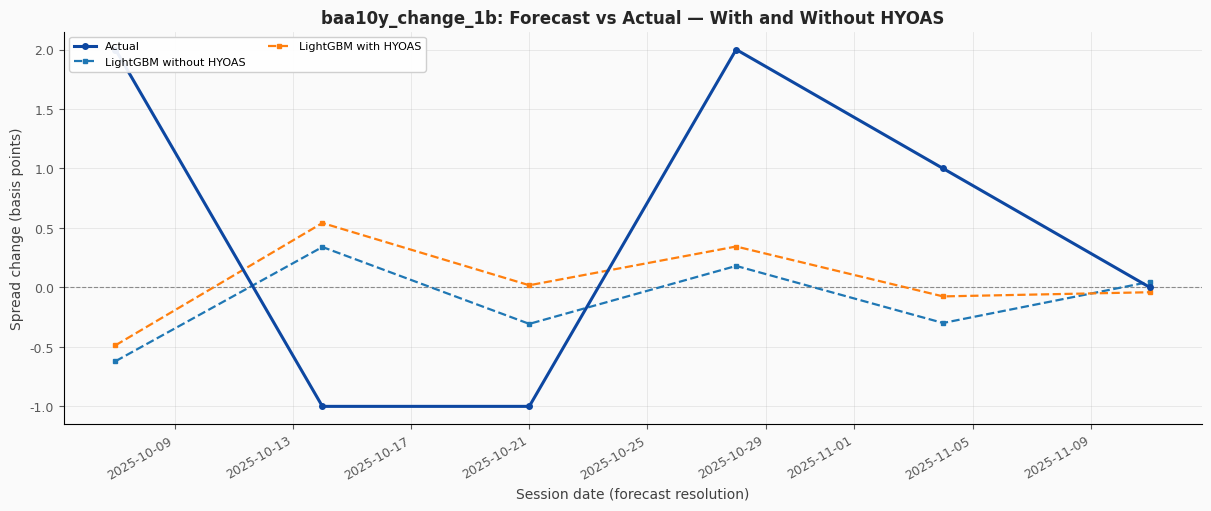

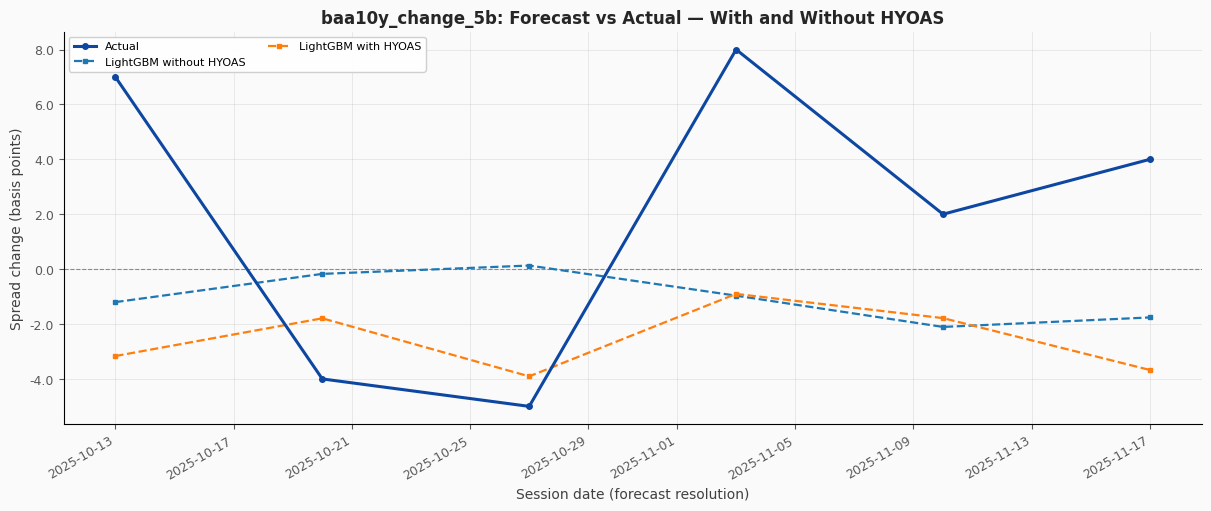

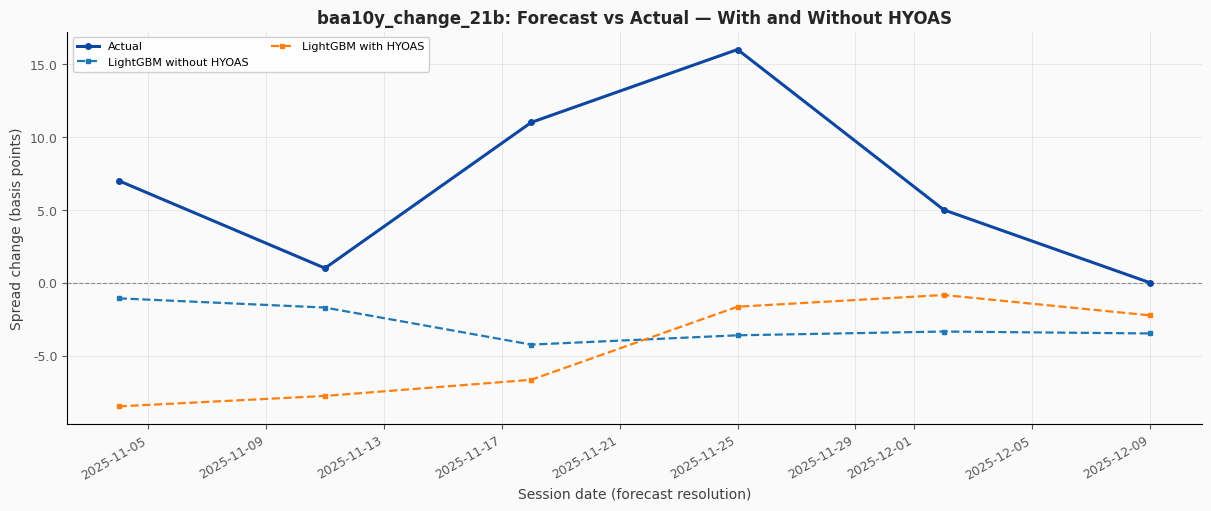

In [28]:
crps_pivot = HYOAS_AB_SUMMARY.pivot(
    index="task",
    columns="experiment",
    values="mean_crps",
)

ax = crps_pivot.plot(
    kind="bar",
    figsize=(11, 5),
    color=["tab:blue", "tab:orange"],
)

ax.set_title(
    "BAA10Y LightGBM Backtest: CRPS With Versus Without HYOAS"
)
ax.set_xlabel("BAA10Y target")
ax.set_ylabel("Mean CRPS — lower is better")
ax.tick_params(axis="x", rotation=0)
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)
ax.legend(title="Experiment")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
    )

plt.tight_layout()
plt.show()

ab_task_ids = [
    "baa10y_change_1b",
    "baa10y_change_5b",
    "baa10y_change_21b",
]

for task_id in ab_task_ids:
    compare_by_run = {}

    for label, task_results in hyoas_comparison_results.items():
        result = task_results.get(task_id)

        if result is None:
            continue

        compare_by_run[label] = build_spread_change_compare_frame(
            result.predictions,
            svc_hyoas,
            task_id,
        )

    if not compare_by_run:
        print(f"No backtest results found for {task_id}")
        continue

    fig, _ = plot_spread_change_forecast_vs_actual_multi(
        compare_by_run,
        title=(
            f"{task_id}: Forecast vs Actual — "
            "With and Without HYOAS"
        ),
    )

    plt.show()

---
## Where to go next

- **Scale up the backtest.** Set `EXPERIMENT_CONFIG = "backtest_2025"` (weekly
  origins across all of 2025, full panel) and re-run from Section 2. The LLMP rows
  are slow over ~50 origins — trim `all_predictors` or widen the spec's `stride`.
- **Study the COVID regime (numerical only).** Set
  `EXPERIMENT_CONFIG = "stress_2020"`: a volatile window where a covariate edge is
  most visible. The predictors cell drops the LLMP rows automatically (2020 is
  pre-cutoff, so an LLM would be reciting, not forecasting).
- **Add a method.** Instantiate any `Predictor` (e.g. another Darts model — mirror
  `aieng/forecasting/methods/numerical/darts_classical.py`) in the predictors
  cell and append it to `all_predictors` with a `PREDICTOR_LABELS` entry. No
  registry or dispatch to edit.
- **Tune the LLM-Process.** Edit `predictors/llmp_sampled_trajectory.py` (prompt
  framing, history window) or pass a different `model=` / `n_samples=` in the
  predictors cell. How do the results move?
- **Try an agentic forecaster** with the same cutoff caveats as the LLMP. Do
  agents add lift over LLMPs or the conventional methods?
- **Spend the eval honestly.** Wire the `EvalTracker` in Section 7 so `max_runs`
  is enforced, and only evaluate models you've committed to.